In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
import corner
import pandas as pd
import h5py

import jax.numpy as jnp
from jesterTOV.inference.flows.flow import Flow
from jesterTOV.utils import redshift_to_luminosity_distance

events = pd.read_csv('../../eos_inference/narrow_ETL/events.dat', sep=" ")
events["cos_theta_jn"] = np.cos(events["theta_jn"])

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

In [3]:
hyperposterior = dict()
with h5py.File("./cosmo_inference/outdir/results.h5") as f:

    for key in ["H0", "Omega0"]:
        hyperposterior[key] = f["posterior"]["parameters"][key][:]
    hyperposterior['log_prob'] = f["posterior"]["log_prob"][:]



FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './cosmo_inference/outdir/results.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

(0.0, 4000.0)

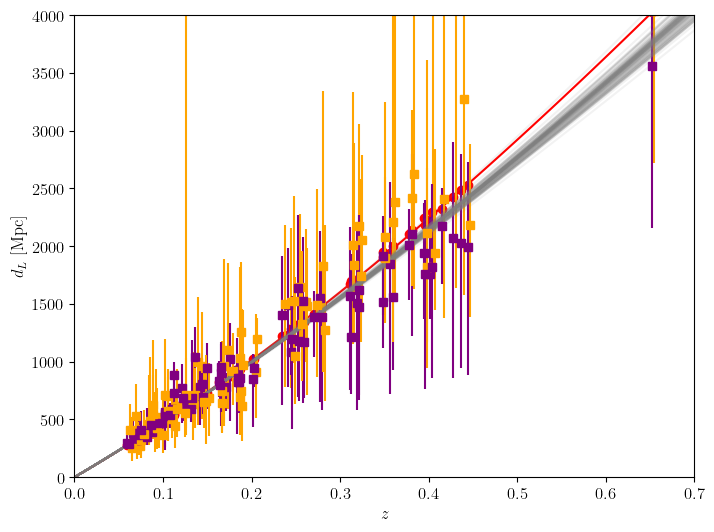

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

quantiles_gw = np.zeros(events.shape[0])
quantiles_em = np.zeros(events.shape[0])

z_arr = np.linspace(0, 0.7, 100)
dL_arr = redshift_to_luminosity_distance(z_arr)
ax.plot(z_arr, dL_arr, color="red")

for src in range(events.shape[0]):

    ax.scatter(events.loc[src, "redshift_measured"], events.loc[src, "luminosity_distance"], color="red")

    posterior_gw = np.load(f"../../eos_inference/narrow_ETL/gw_posteriors/source_{src}/posterior_mm.npz")
    posterior_em = np.load(f"../../eos_inference/narrow_ETL/em_posteriors/source_{src}/posterior.npz")
    quantiles_gw[src] = np.mean(events.loc[src, "luminosity_distance"] >= posterior_gw["luminosity_distance"])
    quantiles_em[src] = np.mean(events.loc[src, "luminosity_distance"] >= posterior_em["luminosity_distance"])

    lower_em, median_em, upper_em = np.quantile(posterior_em["luminosity_distance"], [1/events.shape[0], 0.5, 1-1/events.shape[0]])
    ax.errorbar(events.loc[src, "redshift_measured"]+0.003, median_em, ([median_em-lower_em], [upper_em-median_em]), color="orange", fmt="s")

    lower_gw, median_gw, upper_gw = np.quantile(posterior_gw["luminosity_distance"], [1/events.shape[0], 0.5, 1-1/events.shape[0]])
    ax.errorbar(events.loc[src, "redshift_measured"], median_gw, ([median_gw-lower_gw], [upper_gw-median_gw]), color="purple", fmt="s")


    if events.loc[src, "luminosity_distance"] < lower_em or events.loc[src, "luminosity_distance"] > upper_em:
        print("em problematic: ", src)
    if events.loc[src, "luminosity_distance"] < lower_gw or events.loc[src, "luminosity_distance"] > upper_gw:
        print("gw_problematic: ", src)

for j in range(100):
    z_arr = np.linspace(0, 0.7, 100)
    dL_arr = redshift_to_luminosity_distance(z_arr, H0=hyperposterior["H0"][j], Omega0=hyperposterior["Omega0"][j])
    ax.plot(z_arr, dL_arr, color="grey", alpha=0.1)

ax.set_xlabel("$z$")
ax.set_ylabel("$d_L$ [Mpc]")
ax.set_xlim((0, 0.7))
ax.set_ylim((0, 4000))
#ax.set_yscale("log")


In [ ]:
events.loc[[13, 26, 35, 42, 48, 57, 63, 66], ["redshift", "cos_theta_jn", "thetaCore"]]

,redshift,cos_theta_jn,thetaCore
13,0.201542,-0.973080,0.350712
26,0.201346,-0.993118,0.128182
35,0.652047,0.994823,0.187535
42,0.391046,0.976273,0.085998
48,0.437319,-0.945084,0.400005
57,0.443323,0.999838,0.121054
63,0.186303,0.977625,0.076017
66,0.246729,-0.986422,0.082481


In [ ]:
events.loc[[24, 25, 26, 33, 47, 50, 65], ["redshift", "mass_1_source", "mass_2_source", "luminosity_distance", "prompt_collapse"]]

,redshift,mass_1_source,mass_2_source,luminosity_distance,prompt_collapse
24,0.072353,1.352633,1.346447,337.927485,4
25,0.144014,1.331832,1.226929,704.998149,3
26,0.201346,1.587992,1.332100,1020.106299,1
33,0.087684,1.571735,1.293563,413.837209,1
47,0.412499,1.659793,1.204712,2323.869141,1
50,0.091822,1.319025,1.227053,434.576102,3
65,0.107407,1.366286,1.172936,513.621409,4


In [10]:
events.loc[(events["mass_1_source"]<=1.2) | (events["mass_2_source"]<=1.2), ["mass_1_source", "mass_2_source"] ]

,mass_1_source,mass_2_source
31,1.356782,1.177213
43,1.355440,1.169734
46,1.267986,1.194433
57,1.543723,1.184444
63,1.326579,1.164416
65,1.366286,1.172936
72,1.356258,1.193172


In [5]:
events["mass_2_source"].min()

np.float64(1.164415628912763)

(array([1.44271756, 1.83618598, 1.44271756, 1.44271756, 0.39346842,
        1.04924913, 1.18040527, 0.78693685, 0.52462457, 1.04924913]),
 array([0.01642133, 0.10612133, 0.19582133, 0.28552133, 0.37522133,
        0.46492133, 0.55462133, 0.64432133, 0.73402133, 0.82372133,
        0.91342133]),
 [<matplotlib.patches.Polygon at 0x7efc9c63ed50>])

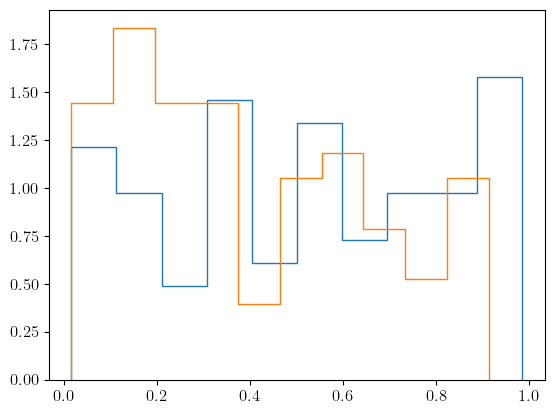

In [ ]:
plt.hist(quantiles_gw, density=True, histtype="step")
plt.hist(quantiles_em, density=True, histtype="step")

Text(0, 0.5, '$d_L$ quantile GW posterior')

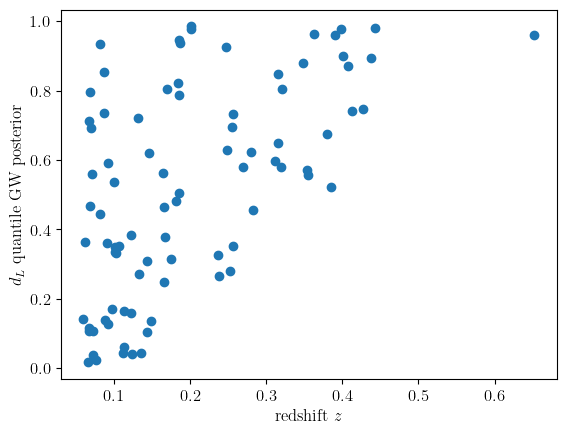

In [6]:
plt.scatter(events["redshift"], quantiles_gw)
#plt.vlines([0.3], *plt.gca().get_ylim(), color="black")
plt.xlabel("redshift $z$")
plt.ylabel("$d_L$ quantile GW posterior")

Text(0, 0.5, '(0, 4000)')

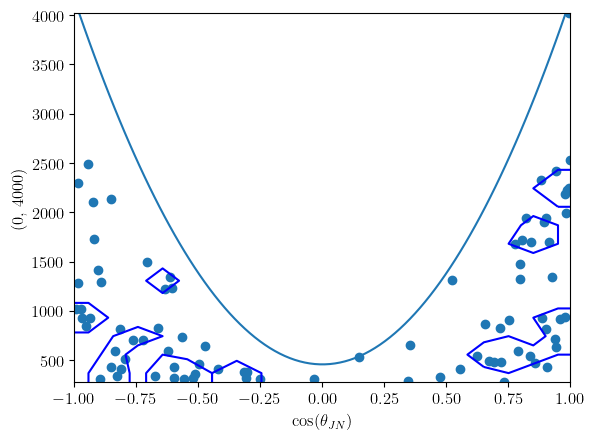

In [38]:
plt.scatter(np.cos(events["theta_jn"]), events["luminosity_distance"])
plt.ylabel("$d_L$")
plt.xlabel("$\\cos(\\theta_{JN})$")

corner.hist2d(np.cos(events["theta_jn"]).to_numpy(), events["luminosity_distance"].to_numpy(), plot_datapoints=False, no_fill_contours=True, color="blue", plot_density=False, levels=[0.95])

u = np.linspace(-1, 1, 100)
plt.plot(u, 460 + 3700* u**2)

plt.xlim((-1, 1))
plt.ylabel((0, 4000))

(-1.0, 1.0)

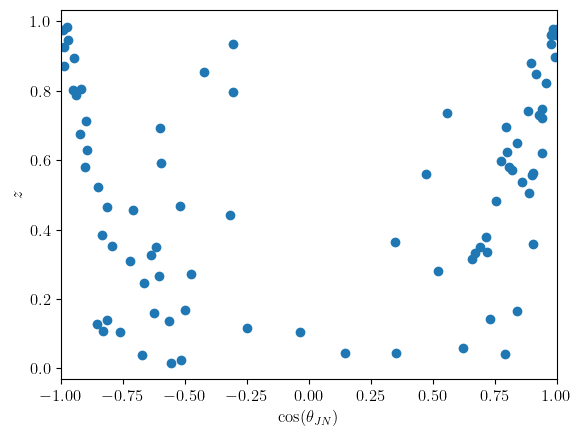

In [5]:
plt.scatter(np.cos(events["theta_jn"]), quantiles_gw)
plt.ylabel("$z$")
plt.xlabel("$\\cos(\\theta_{JN})$")


u = np.linspace(-1, 1, 100)

plt.xlim((-1, 1))


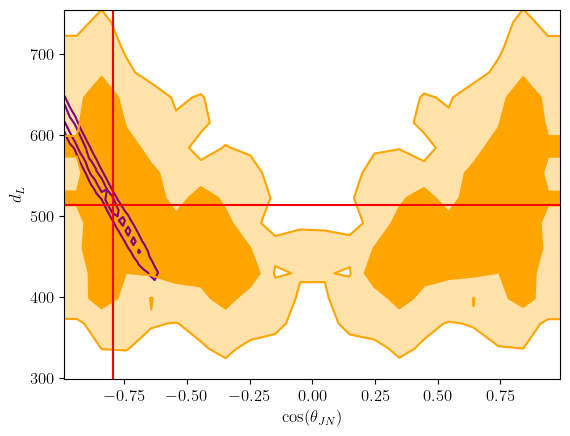

In [17]:
src = 65
posterior_gw = np.load(f"../../eos_inference/narrow_ETL/gw_posteriors/source_{src}/posterior_mm.npz")

corner.hist2d(posterior_gw["cos_theta_jn"], posterior_gw["luminosity_distance"], levels=[0.68, 0.95], plot_density=False, color="purple", plot_datapoints=False, fill_contours=True, smooth=False)

posterior_em = np.load(f"../../eos_inference/narrow_ETL/em_posteriors/source_{src}/posterior.npz")

corner.hist2d(posterior_em["cos_theta_jn"], posterior_em["luminosity_distance"], levels=[0.68, 0.95], plot_density=False, color="orange", plot_datapoints=False, fill_contours=True, smooth=False)
# u = np.linspace(-1, 1, 100)
# plt.plot(u, 500+3500 * u**2, color="black")

plt.xlabel("$\\cos(\\theta_{{JN}})$")
plt.ylabel("$d_L$")
#plt.xlim((0.8, 1))
plt.ylim(posterior_gw["luminosity_distance"].min()-100, posterior_gw["luminosity_distance"].max()+100)

plt.vlines([np.cos(events.loc[src, "theta_jn"])], *plt.gca().get_ylim(), color="red")
plt.hlines([events.loc[src, "luminosity_distance"]], *plt.gca().get_xlim(), color="red")


# Inclinations


gw_problematic:  30


(0.0, 1.0)

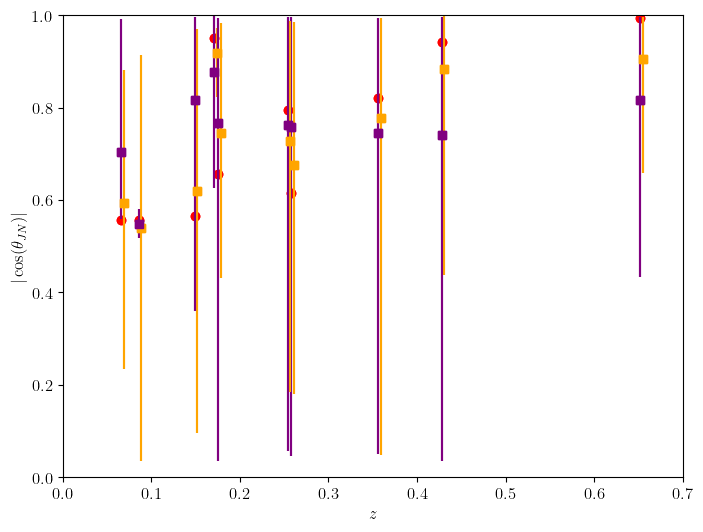

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

quantiles_gw = np.zeros(events.shape[0])
quantiles_em = np.zeros(events.shape[0])


for src in range(events.shape[0]):


    posterior_gw = np.load(f"../../eos_inference/narrow_ETL/gw_posteriors/source_{src}/posterior_mm.npz")
    posterior_em = np.load(f"../../eos_inference/narrow_ETL/em_posteriors/source_{src}/posterior.npz")
    quantiles_gw[src] = np.mean(np.cos(events.loc[src, "theta_jn"]) >= posterior_gw["cos_theta_jn"])
    quantiles_em[src] = np.mean(np.cos(events.loc[src, "theta_jn"]) >= posterior_em["cos_theta_jn"])

    lower_em, median_em, upper_em = np.quantile(np.abs(posterior_em["cos_theta_jn"]), [1/events.shape[0], 0.5, 1-1/events.shape[0]])

    lower_gw, median_gw, upper_gw = np.quantile(np.abs(posterior_gw["cos_theta_jn"]), [1/events.shape[0], 0.5, 1-1/events.shape[0]])


    ax.scatter(events.loc[src, "redshift_measured"], np.abs(np.cos(events.loc[src, "theta_jn"])), color="red")
    ax.errorbar(events.loc[src, "redshift_measured"]+0.003, median_em, ([median_em-lower_em], [upper_em-median_em]), color="orange", fmt="s")
    ax.errorbar(events.loc[src, "redshift_measured"], median_gw, ([median_gw-lower_gw], [upper_gw-median_gw]), color="purple", fmt="s")

    ax.scatter(events.loc[src, "redshift_measured"], np.abs(np.cos(events.loc[src, "theta_jn"])), color="red")
    ax.errorbar(events.loc[src, "redshift_measured"]+0.003, median_em, ([median_em-lower_em], [upper_em-median_em]), color="orange", fmt="s")
    ax.errorbar(events.loc[src, "redshift_measured"], median_gw, ([median_gw-lower_gw], [upper_gw-median_gw]), color="purple", fmt="s")

    if np.abs(np.cos(events.loc[src, "theta_jn"])) < lower_em or np.abs(np.cos(events.loc[src, "theta_jn"]))  > upper_em:
        print("em problematic: ", src)

    if np.abs(np.cos(events.loc[src, "theta_jn"]))  < lower_gw or np.abs(np.cos(events.loc[src, "theta_jn"]))  > upper_gw:
        print("gw_problematic: ", src)



ax.set_xlabel("$z$")
ax.set_ylabel("$|\\cos(\\theta_{JN})|$")
ax.set_xlim((0, 0.7))
ax.set_ylim((0, 1))


In [6]:
events.loc[[4, 37, 42, 63], ["theta_jn", "thetaCore"]]

,theta_jn,thetaCore
4,0.440544,0.126028
37,2.828137,0.112620
42,0.218273,0.085998
63,0.211937,0.076017


(array([1.41235978, 0.82387654, 1.29466313, 0.94157319, 0.58848324,
        0.2353933 , 0.58848324, 1.05926984, 1.29466313, 1.76544973]),
 array([4.21333333e-04, 1.00379200e-01, 2.00337067e-01, 3.00294933e-01,
        4.00252800e-01, 5.00210667e-01, 6.00168533e-01, 7.00126400e-01,
        8.00084267e-01, 9.00042133e-01, 1.00000000e+00]),
 [<matplotlib.patches.Polygon at 0x7f5f4f296d50>])

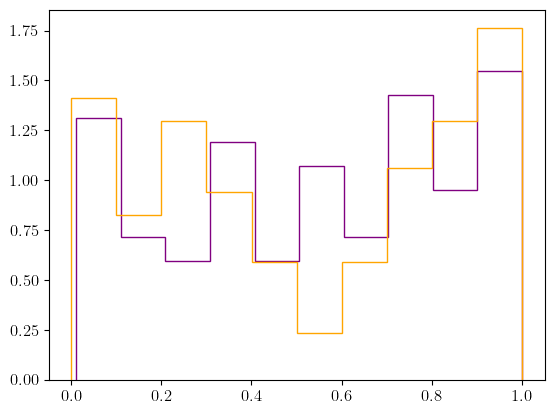

In [7]:
plt.hist(quantiles_gw, color="purple", histtype="step", density=True)
plt.hist(quantiles_em, color="orange", histtype="step", density=True)

Text(0, 0.5, '$\\cos(\\theta_{JN})$ quantile GW posterior')

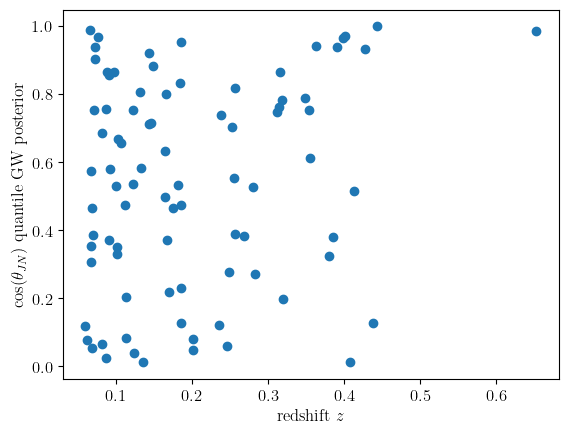

In [4]:
plt.scatter(events["redshift"], quantiles_gw)
#plt.vlines([0.3], *plt.gca().get_ylim(), color="black")
plt.xlabel("redshift $z$")
plt.ylabel("$\\cos(\\theta_{JN})$ quantile GW posterior")

In [21]:
events["luminosity_distance"].max()

np.float64(4024.1730108837646)